In [1]:
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.pyplot import plot, ion, show, savefig, cla, figure
from pathlib import Path
from tqdm import tqdm

import torch
import torch.optim as optim
import torch.nn.functional as F

from models import VAE_LSTM_MA, VAE_LSTM_Linear, VAE_LSTM_Local, MA_VAE
from data_loader import DataGenerator
from utils import process_config, create_dirs
from train import load_latest_vae_checkpoint, set_random_seeds

In [3]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # keep GPU ordering consistent
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [4]:
# load VAE model
config = process_config('config.json')
# create the experiments dirs
create_dirs([config['result_dir'], config['checkpoint_dir']])
# create your data generator
data = DataGenerator(config)

In [5]:
seed = config.get('random_seed', 42)
set_random_seeds(seed)

In [6]:
# create a VAE model and load the latest checkpoint
if config['exp_name'] == 'vae-lstm-dual-ma':
    model = VAE_LSTM_MA(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'vae-lstm-dual-linear':
    model = VAE_LSTM_Linear(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'vae-lstm-local-only':
    model = VAE_LSTM_Local(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'ma-vae':
    model = MA_VAE(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), amsgrad=True)
else:
    raise ValueError(f"Unknown experiment name: {config['exp_name']}")

if not load_latest_vae_checkpoint(model, optimizer, device, config['checkpoint_dir']):
    raise RuntimeError("No checkpoint found to load.")
model.eval()

Loaded VAE checkpoint: experiments/vae-lstm-dual-ma/batch-512/vae-lstm-dual-ma-144-24-1-12/checkpoint/vae_checkpoint_epoch_100.pth


VAE_LSTM_MA(
  (encoder): VAE_Encoder(
    (local_module): LocalModule(
      (enc_conv1): Sequential(
        (0): Conv2d(55, 64, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv4): Sequential(
        (0): Conv2d(256, 512, kernel_size=(4, 1), stride=(1, 1))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_fc): Sequential(
        (0): Linear(in_features=512, out_features=48, bias=True)
        (1): LeakyReLU(negative_slope=0.2)
      )
    )
    (global_module): GlobalModule(
      (enc_conv1): Sequential(
        (0): Conv1d(55, 64, kernel_size=(7,), stride=(3,), padding=(3,))
      

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 1,606,527 trainable parameters


In [8]:
if config['load_dir'] == 'default' or config['load_dir'] == 'experiments':
    data_dir = Path('../data')
elif config['load_dir'] == 'experiments_2':
    data_dir = Path('../data_2')
elif config['load_dir'] == 'experiments_3':
    data_dir = Path('../data_3')
else:
    raise ValueError("Invalid load_dir in config.json")

train_df = pd.read_csv(data_dir / 'train.csv')
train_df = train_df.drop(columns=['subject_id', 'label'])

train_m = train_df.mean().values[0]
train_std = train_df.std().values[0]

train_df_with_anomaly = pd.read_csv(data_dir / 'train_with_anomaly.csv')
train_df_subjects_with_anomaly = train_df_with_anomaly.pop('subject_id')
train_df_labels_with_anomaly = train_df_with_anomaly.pop('label')

test_df = pd.read_csv(data_dir / 'test.csv')
test_subjects = test_df.pop('subject_id')
test_labels = test_df.pop('label')

train_loader, val_loader, test_loader = data.get_dataloaders(test=True)

In [9]:
def evaluate_model(data_loader):
    batch_recons_error = []
    
    for batch_data in tqdm(data_loader):
        if isinstance(batch_data, (list, tuple)):
            batch_data = batch_data[0]
        batch_data = batch_data.to(device)
        with torch.no_grad():
            reconstruction = model(batch_data)
            Xhat = reconstruction[0]
                        
            batch_data = batch_data.view(Xhat.size(0), -1, Xhat.size(2), Xhat.size(3))
            batch_data = batch_data[:, 1:, :, :]  # Align batch_data with the number of windows
            
            recon_loss = torch.sum((batch_data - Xhat).pow(2), dim=[1, 2, 3])
            
            batch_recons_error.append(recon_loss.cpu().numpy())
    
    batch_recons_error = np.concatenate(batch_recons_error, axis=0)
    
    return batch_recons_error

def evaluate_model_ma_vae(data_loader):
    batch_recons_error = []
    
    for batch_data in tqdm(data_loader):
        if isinstance(batch_data, (list, tuple)):
            batch_data = batch_data[0]
        batch_data = batch_data.to(device)
        with torch.no_grad():
            reconstruction = model(batch_data)
            Xhat = reconstruction[2]
            
            recon_loss = torch.sum((batch_data - Xhat).pow(2), dim=(1,2))            
            batch_recons_error.append(recon_loss.cpu().numpy())
    
    batch_recons_error = np.concatenate(batch_recons_error, axis=0)
    
    return batch_recons_error

In [10]:
from scipy.stats import norm
def plot_histogram(test_anomaly_metric, n_bins, title, mean=None, std=None, xlim=None, saveplot=False):
    test_anomaly_list = np.squeeze(np.ndarray.flatten(test_anomaly_metric))
    his = plt.hist(test_anomaly_list, bins=n_bins, density=True)
    if mean is None and std is None:
        mean = np.mean(test_anomaly_list)
        std = np.std(test_anomaly_list)
        legend_label = None
    else:
        legend_label = 1
    x_axis = np.arange(mean-5*std, mean+5*std, std/100)
    plt.plot(x_axis, norm.pdf(x_axis,mean,std))
    plt.title(title)
    plt.xlabel('anomaly score value')
    plt.ylabel('probability density')
    if xlim is not None:
        plt.xlim(0, xlim)
    else:
        plt.xlim(0, np.amax(test_anomaly_list))
    if legend_label is None:
        plt.legend(('Fitted Gaussian', 'histogram'))
    else:
        plt.legend(('normal data distribution','test data distribution (contain anomalies)'))
    if saveplot:
        savefig(config['result_dir']+'reconstruction_error_histogram.pdf')
    else:
        plt.show()
    threshold_25 = np.percentile(test_anomaly_list, 25)
    threshold_75 = np.percentile(test_anomaly_list, 75)
    threshold_1 = np.percentile(test_anomaly_list, 99)
    idx_large_error = np.argwhere(test_anomaly_metric.flatten() > threshold_1)
#     print(his[0][-20:])
#     print(his[1][-20:])
    print("25% percentile: {}".format(threshold_25))
    print("75% percentile: {}".format(threshold_75))
#     print("Median: {}".format(np.median(test_anomaly_list)))
#     print("Mean: {}".format(np.mean(test_anomaly_list)))
#     print("Std dev: {}".format(np.std(test_anomaly_list)))
    print("These windows scored the top 1% of anomaly metric ({}): \n{}".format(threshold_1, idx_large_error))
    return mean, std

In [11]:
if config['exp_name'] == 'ma-vae':
    train_score = evaluate_model_ma_vae(train_loader)
else:
    train_score = evaluate_model(train_loader)

100%|██████████| 106/106 [00:01<00:00, 77.36it/s]


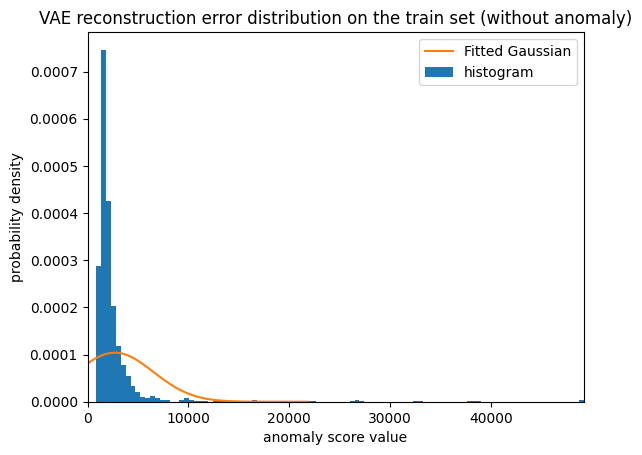

25% percentile: 1497.407958984375
75% percentile: 2547.885986328125
These windows scored the top 1% of anomaly metric (22425.546875): 
[[  180]
 [  214]
 [  304]
 [  330]
 [  381]
 [  439]
 [  663]
 [  672]
 [  684]
 [  859]
 [  966]
 [ 1006]
 [ 1029]
 [ 1114]
 [ 1286]
 [ 1309]
 [ 1342]
 [ 1416]
 [ 1440]
 [ 1483]
 [ 1550]
 [ 1591]
 [ 1601]
 [ 1621]
 [ 1682]
 [ 1707]
 [ 1853]
 [ 2139]
 [ 2313]
 [ 2346]
 [ 2355]
 [ 2568]
 [ 2581]
 [ 2602]
 [ 2671]
 [ 2829]
 [ 3106]
 [ 3250]
 [ 3513]
 [ 3533]
 [ 3605]
 [ 4059]
 [ 4127]
 [ 4130]
 [ 4156]
 [ 4162]
 [ 4619]
 [ 4628]
 [ 4664]
 [ 4751]
 [ 4867]
 [ 5000]
 [ 5260]
 [ 5262]
 [ 5321]
 [ 5418]
 [ 5482]
 [ 5530]
 [ 5647]
 [ 5727]
 [ 5791]
 [ 5896]
 [ 5938]
 [ 5942]
 [ 6068]
 [ 6086]
 [ 6177]
 [ 6183]
 [ 6203]
 [ 6376]
 [ 6385]
 [ 6393]
 [ 6983]
 [ 7089]
 [ 7235]
 [ 7272]
 [ 7290]
 [ 7397]
 [ 7497]
 [ 7523]
 [ 7558]
 [ 7576]
 [ 7593]
 [ 7598]
 [ 7619]
 [ 7768]
 [ 7842]
 [ 7896]
 [ 8036]
 [ 8118]
 [ 8241]
 [ 8381]
 [ 8401]
 [ 8475]
 [ 8490]
 [ 8622]
 

(np.float32(2702.8013), np.float32(3836.2288))

In [12]:
plot_histogram(train_score, 100, 'VAE reconstruction error distribution on the train set (without anomaly)', mean=None, std=None, xlim=None)

In [13]:
if config['exp_name'] == 'ma-vae':
    val_score = evaluate_model_ma_vae(val_loader)
else:
    val_score = evaluate_model(val_loader)

100%|██████████| 12/12 [00:00<00:00, 91.24it/s]


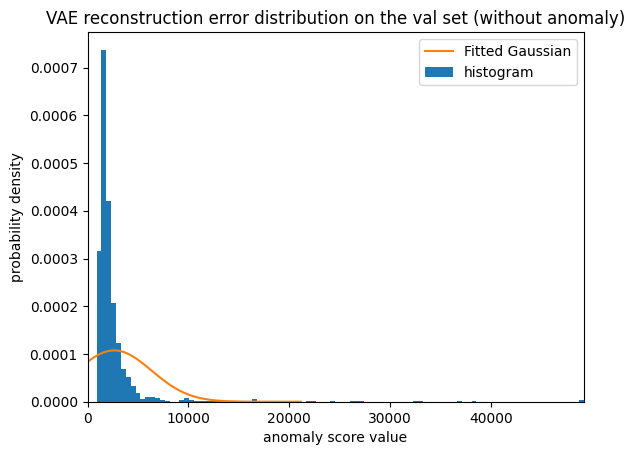

25% percentile: 1494.780029296875
75% percentile: 2514.471435546875
These windows scored the top 1% of anomaly metric (22082.896484375): 
[[  18]
 [ 411]
 [ 533]
 [ 551]
 [ 648]
 [ 654]
 [ 657]
 [ 723]
 [ 828]
 [ 839]
 [ 883]
 [1247]
 [1288]
 [1339]
 [1343]
 [1361]
 [1363]
 [1570]
 [1660]
 [1804]
 [1942]
 [1944]
 [2018]
 [2051]
 [2383]
 [2469]
 [2613]
 [2618]
 [2963]
 [3000]
 [3077]
 [3117]
 [3227]
 [3438]
 [3533]
 [3544]
 [3696]
 [3987]
 [4106]
 [4131]
 [4152]
 [4427]
 [4434]
 [4571]
 [4616]
 [4634]
 [4672]
 [4717]
 [4736]
 [4933]
 [5163]
 [5188]
 [5206]
 [5323]
 [5457]
 [5694]
 [5768]
 [5802]
 [5835]
 [5962]
 [5992]]


(np.float32(2640.2786), np.float32(3710.371))

In [14]:
plot_histogram(val_score, 100, 'VAE reconstruction error distribution on the val set (without anomaly)', mean=None, std=None, xlim=None)

In [15]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

if config['exp_name'] == 'ma-vae':
    test_score = evaluate_model_ma_vae(test_loader)
else:
    test_score = evaluate_model(test_loader)

end_event.record()

torch.cuda.synchronize()

elapsed_time = start_event.elapsed_time(end_event)
print(f"Test Set Inference Time: {elapsed_time * 1e-3} seconds")

100%|██████████| 88/88 [00:00<00:00, 109.12it/s]

Test Set Inference Time: 0.8087105712890625 seconds


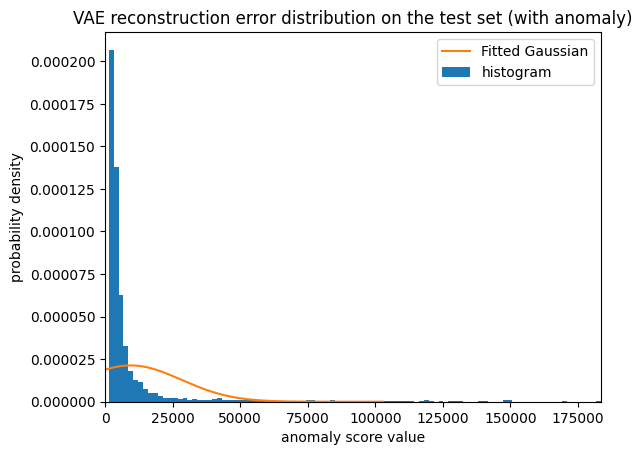

25% percentile: 2701.39697265625
75% percentile: 7000.2041015625
These windows scored the top 1% of anomaly metric (111369.4375): 
[[ 2184]
 [ 2185]
 [ 2186]
 [ 2187]
 [ 2188]
 [ 2189]
 [ 2190]
 [ 2191]
 [ 2192]
 [ 2193]
 [ 2194]
 [ 2195]
 [ 2196]
 [ 2197]
 [ 2198]
 [ 2199]
 [ 2200]
 [ 2201]
 [ 2202]
 [ 2203]
 [ 2204]
 [ 2205]
 [ 2206]
 [ 2207]
 [ 2208]
 [ 2209]
 [ 2210]
 [ 2211]
 [ 2212]
 [ 2213]
 [ 2214]
 [ 2215]
 [ 2216]
 [ 2217]
 [ 2218]
 [ 2219]
 [ 2220]
 [ 2221]
 [ 2222]
 [ 2223]
 [ 2224]
 [ 2225]
 [ 2226]
 [ 2227]
 [ 2228]
 [ 2229]
 [ 2230]
 [ 2231]
 [ 2232]
 [ 2233]
 [ 2234]
 [ 2235]
 [ 2236]
 [ 2237]
 [ 2238]
 [ 2239]
 [ 2240]
 [ 2241]
 [ 2242]
 [ 2243]
 [ 2244]
 [ 2245]
 [ 2246]
 [ 2247]
 [ 2248]
 [ 2249]
 [ 2250]
 [ 2251]
 [ 2252]
 [ 2253]
 [ 2254]
 [ 2255]
 [ 2256]
 [ 2257]
 [ 2258]
 [ 2259]
 [ 2260]
 [ 2261]
 [ 2262]
 [ 2263]
 [ 2264]
 [ 2265]
 [ 2266]
 [ 2267]
 [ 2268]
 [ 2269]
 [ 2270]
 [ 2271]
 [ 2272]
 [ 2273]
 [ 2274]
 [ 2275]
 [ 2276]
 [ 2277]
 [ 2278]
 [ 2279]
 [ 22

(np.float32(9474.603), np.float32(18707.178))

In [16]:
plot_histogram(test_score, 100, 'VAE reconstruction error distribution on the test set (with anomaly)', mean=None, std=None, xlim=None)

In [17]:
idx_anomaly_test = test_labels[test_labels == 1].index.to_numpy()
n_test = len(data.test_set)
test_labels_vae = np.zeros(n_test)
anomaly_index_vae = []
for i in tqdm(range(len(idx_anomaly_test))):
    idx_start = (idx_anomaly_test[i] - config['window_size']) // config['window_shift']
    idx_end = idx_anomaly_test[i] // config['window_shift'] + 1
    
    if idx_start < 0:
        idx_start = 0
    
    if idx_end > n_test:
        idx_end = n_test
    
    anomaly_index_vae.append(np.arange(idx_start,idx_end))
    test_labels_vae[idx_start:idx_end] = 1

print(test_labels_vae.shape)

100%|██████████| 13684/13684 [00:00<00:00, 703489.03it/s]

(44589,)


In [18]:
def return_anomaly_idx_by_threshold(test_anomaly_metric, threshold):
    idx_error = np.flatnonzero(test_anomaly_metric > threshold)
    if len(idx_error.shape) == 0:
        idx_error = np.expand_dims(idx_error, 0)
    return idx_error

In [19]:
def augment_detected_idx(idx_detected_anomaly, anomaly_index):
    idx_detected_anomaly_set = set(idx_detected_anomaly)
    idx_detected_anomaly_extended = set(idx_detected_anomaly)
    
    # anomaly_index는 이상 구간(리스트의 리스트)이라고 가정
    for anomaly_win in anomaly_index:
        # 현재 이상 구간(anomaly_win)이 기존 탐지에 포함되었는지 확인
        # set intersection이 빠름
        if idx_detected_anomaly_set.intersection(anomaly_win):
            # 포함되었다면 해당 구간 전체를 확장된 set에 추가
            idx_detected_anomaly_extended.update(anomaly_win)

    # numpy로 변환 후 정렬
    return np.sort(np.array(list(idx_detected_anomaly_extended), dtype=int))

In [20]:
def count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels):  
    detected_labels = test_labels[idx_detected_anomaly]
    n_TP = np.sum(detected_labels == 1)
    n_FP = np.sum(detected_labels == 0)
    n_TN = np.sum(test_labels == 0) - n_FP
    n_FN = np.sum(test_labels == 1) - n_TP
    
    return n_TP, n_TN, n_FP, n_FN, 

In [21]:
def compute_precision_and_recall(idx_detected_anomaly, anomaly_index, test_labels):
    n_TP, n_TN, n_FP, n_FN = count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels)
    
    precision = n_TP / (n_TP + n_FP) if (n_TP + n_FP) > 0 else 1.0
    recall = n_TP / (n_TP + n_FN) if (n_TP + n_FN) > 0 else 0.0
    accuracy = (n_TP + n_TN) / (n_TP + n_FP + n_FN + n_TN) if (n_TP + n_FP + n_FN + n_TN) > 0 else 0.0
    F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, accuracy, F1, n_TP, n_TN, n_FP, n_FN

In [22]:
def slice_detected_indices_into_seq(idx_detection, interval): # interval: max gap between consecutive indices in a sequence
    detected_seq = []
    i = 0
    while i < len(idx_detection):
        if i == 0:
            cur_seq = [idx_detection[i]]
            i = i + 1
        else:
            if idx_detection[i] - idx_detection[i-1] > interval:
                detected_seq.append(cur_seq)
                cur_seq = [idx_detection[i]]
            else:
                cur_seq.append(idx_detection[i])
                if i == len(idx_detection) - 1:
                    detected_seq.append(cur_seq)
            i = i + 1
    
    print("Detected {} sequences".format(len(detected_seq)))
    return detected_seq

In [23]:
def plot_detected_anomalies(idx_detection, config, result, detection_method, augmented_flag=1, y_scale=5, y_lim=None):
    interval = config['window_size'] // config['window_shift']
    detected_seq = slice_detected_indices_into_seq(idx_detection, interval=interval)
    t_test = result['t_test']
    test = result['test']
    idx_anomaly_test = result['idx_anomaly_test']
        
    # plot detected sequences
    fig, axs = plt.subplots(1, 1, figsize=(18, 5), edgecolor='k')
    fig.subplots_adjust(hspace=.4, wspace=.4)
    axs.plot(t_test, test[:, 0]) # plot only the first channel
    for j in range(len(idx_anomaly_test)):
        if j == 0:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-', label='true anomalies')
        else:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-')
        
    for i in range(len(detected_seq)):
        for j in detected_seq[i]:
            if j == detected_seq[0][0]:
                axs.plot((j * config['window_shift'] + config['window_size']) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-', label='detected anomalies')
            else:
                axs.plot((j * config['window_shift'] + config['window_size']) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-')

    for j in range(len(idx_anomaly_test)):
        axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r--')

    for i in range(len(detected_seq)):
        interval_x = np.asarray([detected_seq[i][0] * config['window_shift'], detected_seq[i][-1] * config['window_shift'] + config['window_size']])
        interval_y = np.asarray([y_scale,y_scale])
        if i == 0:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y', label='detected anomaly windows')
        else:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
        interval_y = np.asarray([-y_scale,-y_scale])
        axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
    axs.grid(True)
    axs.set_xlim(0, len(t_test))
    if y_lim is None:
        axs.set_ylim(-y_scale, y_scale)
    else:
        axs.set_ylim(-y_scale, y_lim)
    axs.set_xlabel("timestamp (every {})".format(result['t_unit']))
    axs.set_title(f"dataset test sequence\n Detection method: {detection_method}")
    axs.legend()
    savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))

In [24]:
result = {}
result['t_test'] = test_df.index.values
result['test'] = (test_df.values - train_m) / train_std
result['train_m'] = train_m
result['train_std'] = train_std
result['t_unit'] = '0.25 sec'
result['idx_anomaly_test'] = np.flatnonzero(test_labels.values == 1)

In [25]:
percentile_list = np.arange(0, 100.1, 1)
threshold_list = np.percentile(test_score, percentile_list)

n_threshold = len(threshold_list)

precision = np.zeros(n_threshold)
recall = np.zeros(n_threshold)
accuracy = np.zeros(n_threshold)
F1 = np.zeros(n_threshold)

precision_aug = np.zeros(n_threshold)
recall_aug = np.zeros(n_threshold)
accuracy_aug = np.zeros(n_threshold)
F1_aug = np.zeros(n_threshold)

for i, threshold in tqdm(enumerate(threshold_list)):
    #print(threshold_list[i])
    idx_detection_vae = return_anomaly_idx_by_threshold(test_score, threshold)
    precision[i], recall[i], accuracy[i], F1[i], _, _, _, _ = compute_precision_and_recall(idx_detection_vae, 
                                                                           anomaly_index_vae, 
                                                                           test_labels_vae)
    # augment the detection using the ground truth labels
    # a method to discount the factor one anomaly appears in multiple consecutive windows
    # introduced in "Unsupervised anomaly detection via variational auto-encoder for seasonal kpis in web applications"
    idx_detection_vae_augmented = augment_detected_idx(idx_detection_vae, anomaly_index_vae)
    precision_aug[i], recall_aug[i], accuracy_aug[i], F1_aug[i], _, _, _, _ = compute_precision_and_recall(idx_detection_vae_augmented, 
                                                                                       anomaly_index_vae, 
                                                                                       test_labels_vae)

101it [00:14,  7.18it/s]


In [26]:
print("Best F1 score is {}".format(np.amax(F1)))
idx_best_threshold = np.squeeze(np.argmax(F1))
print("Best threshold is {}".format(threshold_list[idx_best_threshold]))
print("Precision is {}, recall is {}, accuracy is {}".format(precision[idx_best_threshold], recall[idx_best_threshold], accuracy[idx_best_threshold]))

print("\nAugmented detection:")
print("Best F1 score is {}".format(np.amax(F1_aug)))
idx_best_threshold = np.squeeze(np.argmax(F1_aug))
print("Best threshold is {}".format(threshold_list[idx_best_threshold]))
print("Precision is {}, recall is {}, accuracy is {}".format(precision_aug[idx_best_threshold], recall_aug[idx_best_threshold], accuracy_aug[idx_best_threshold]))

Best F1 score is 0.7363636363636363
Best threshold is 4214.2279296875
Precision is 0.6358122228452011, recall is 0.874693219269336, accuracy is 0.799681535804795

Augmented detection:
Best F1 score is 0.8541653587795843
Best threshold is 6070.1828125
Precision is 0.7731999772688527, recall is 0.9540705420377252, accuracy is 0.8958038978223328


In [27]:
# Now select a threshold
threshold = threshold_list[np.squeeze(np.argmax(F1_aug))]

print("Threshold is {}".format(threshold))
idx_detection = return_anomaly_idx_by_threshold(test_score, threshold)
idx_detection_augmented = augment_detected_idx(idx_detection, anomaly_index_vae)
precision, recall, accuracy, F1, n_TP, n_TN, n_FP, n_FN = compute_precision_and_recall(idx_detection_augmented, 
                                                                       anomaly_index_vae, 
                                                                       test_labels_vae)
print("\nPR evaluation using augmented detection:")
print("Precision: {}".format(precision))
print("Recall: {}".format(recall))
print("Accuracy: {}".format(accuracy))
print("F1: {}".format(F1))
print("TP: {}".format(n_TP))
print("TN: {}".format(n_TN))
print("FP: {}".format(n_FP))
print("FN: {}".format(n_FN))

Threshold is 6070.1828125

PR evaluation using augmented detection:
Precision: 0.7731999772688527
Recall: 0.9540705420377252
Accuracy: 0.8958038978223328
F1: 0.8541653587795843
TP: 13606
TN: 26337
FP: 3991
FN: 655


Detected 27 sequences


/tmp/ipykernel_284222/1492443606.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/tmp/ipykernel_284222/1492443606.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


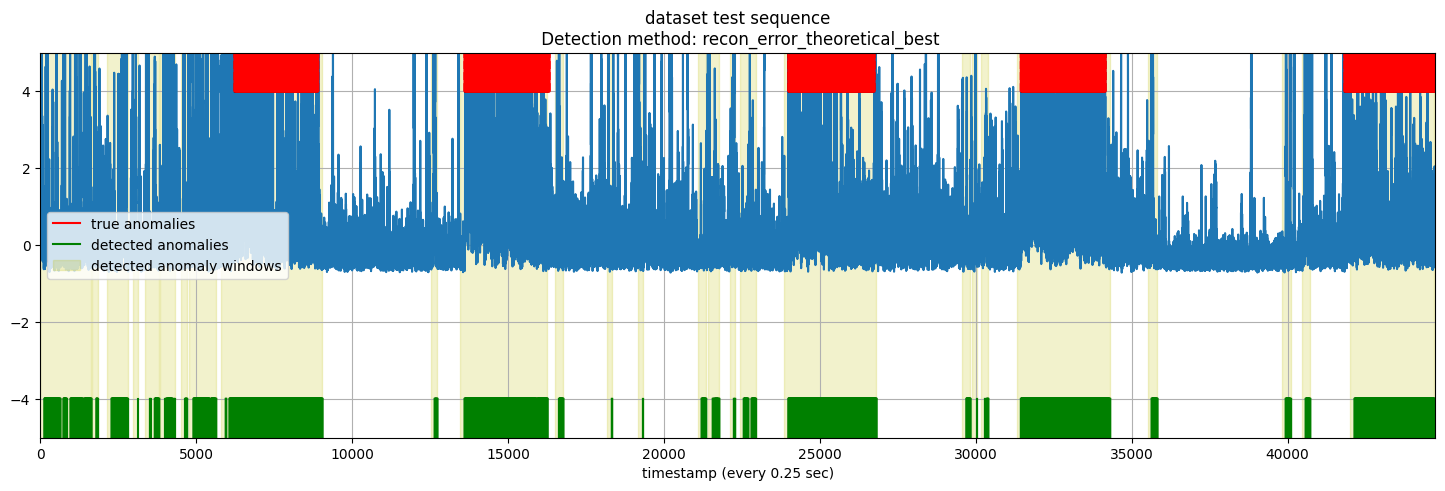

In [28]:
plot_detected_anomalies(idx_detection_augmented, 
                        config=config,
                        result=result, 
                        detection_method='recon_error_theoretical_best',
                        augmented_flag=1,
                        y_scale=5,
                        y_lim=5)

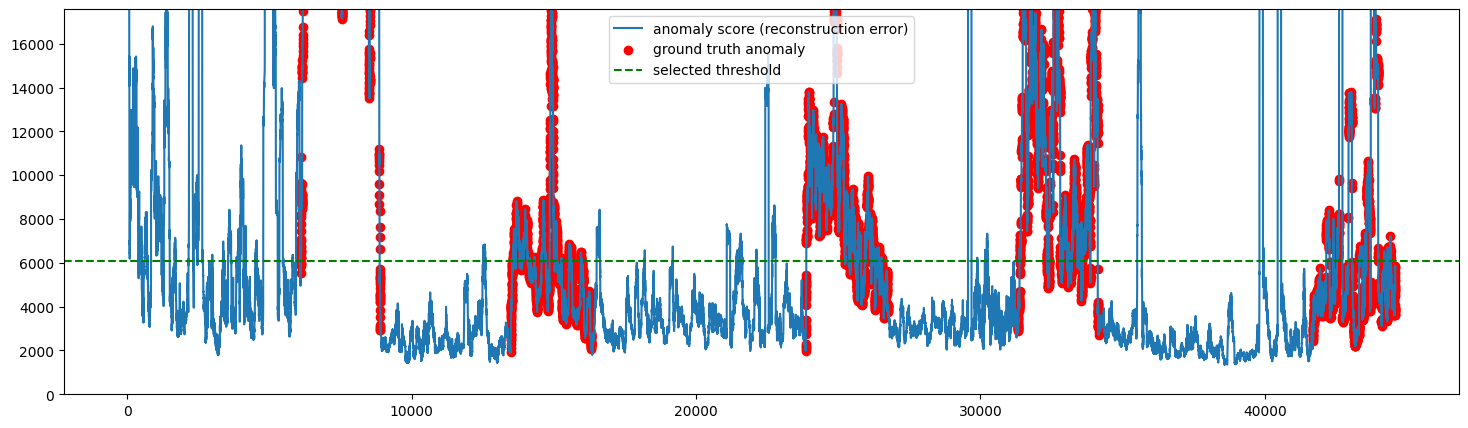

In [ ]:
# Plot test_score, colored by ground truth. Draw threshold line
plt.figure(figsize=(18,5))
plt.plot(test_score, label='anomaly score (reconstruction error)')
plt.scatter(np.flatnonzero(test_labels_vae==1), test_score[test_labels_vae==1], color='r', label='ground truth anomaly')
plt.axhline(y=threshold, color='g', linestyle='--', label='selected threshold')
plt.legend()